<style>
    .vse-report-wrapper {
        max-width: 800px;
        margin: 40px auto;
        padding: 60px;
        border: 1px solid #e2e8f0;
        border-radius: 8px;
        background-color: #ffffff;
        font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif;
        box-shadow: 0 15px 35px rgba(0,0,0,0.05);
        color: #1a202c;
        /* Ensures everything inside the main container is centered */
        display: flex;
        flex-direction: column;
        align-items: center;
    }

    .vse-logo {
        width: 140px;
        height: auto;
        margin-bottom: 30px;
    }

    .vse-blue-divider {
        height: 3px;
        background-color: #469CDA; 
        width: 80px;
        margin: 20px auto;
    }

    .text-center-group {
        text-align: center !important;
        width: 100%;
    }

    .course-subtitle {
        font-size: 1.1rem;
        text-transform: uppercase;
        text-align: center !important;
        letter-spacing: 3px;
        color: #718096;
        margin: 0;
    }

    .project-header-title {
        font-size: 2.6rem;
        font-weight: 800;
        line-height: 1.1;
        margin: 15px 0;
        color: #469CDA; 
    }

    .doc-type {
        color: #718096;
        text-align: center !important;
        font-size: 1rem;
        margin-top: 5px;
        width: 100%;
    }

    .author-grid {
        display: grid;
        grid-template-columns: repeat(4, 1fr);
        width: 100%;
        margin-top: 50px;
        border-top: 1px solid #edf2f7;
        padding-top: 30px;
    }

    .author-item {
        text-align: center;
    }

    .author-label {
        display: block;
        font-size: 0.75rem;
        text-transform: uppercase;
        color: #718096;
        margin-bottom: 4px;
    }

    .author-name {
        font-weight: 600;
        color: #2d3748;
    }

    .prof-footer {
        margin-top: 50px;
        text-align: center;
        width: 100%;
        border-top: 1px solid #edf2f7;
        padding-top: 30px;
    }

    .prof-name {
        font-size: 1.1rem;
        color: #2d3748;
        text-align: center !important;
        margin-bottom: 5px;
    }

    .submission-date {
        font-size: 0.9rem;
        color: #718096;
        text-align: center !important;
    }
</style>

<div class="vse-report-wrapper">
    <img src="https://pr.vse.cz/wp-content/uploads/page/58/VSE_logo_CZ_circle_blue.png" class="vse-logo" alt="VSE Prague Logo">
    <div class="text-center-group">
        <p class="course-subtitle">Machine Learning I</p>
        <div class="vse-blue-divider"></div>
        <h1 class="project-header-title">Analysis of customer churn</h1>
        <p class="doc-type">Jupyter Notebook Documentation</p>
    </div>
    <div class="author-grid">
        <div class="author-item">
            <span class="author-label">Author</span>
            <span class="author-name">Anna Kopecny</span>
        </div>
        <div class="author-item">
            <span class="author-label">Author</span>
            <span class="author-name">Adil Zhumagaliyev</span>
        </div>
        <div class="author-item">
            <span class="author-label">Author</span>
            <span class="author-name">Alisha Utegenova</span>
        </div>
        <div class="author-item">
            <span class="author-label">Author</span>
            <span class="author-name">Assylbek Omarov</span>
        </div>
    </div>
    <div class="prof-footer">
        <p class="prof-name"><strong>Professor:</strong> prof. Ing. Tomáś Kliegr, Ph.D.</p>
        <p class="prof-name"> <strong>Seminar:</strong> Monday 18:00 - 19:30</p>
        <p class="submission-date">March 2026</p>
    </div>
</div>

# Introduction

1.	Describe the business value of addressing this problem with machine learning. 

Answer: It costs significantly more to acquire a new customer than to retain an existing one. Predicting churn allows the business to proactively offer targeted promotions to at-risk customers, maximizing revenue.

2.	Provide the link to the source of the data. 
Link: https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset 

## Customization

1.	What is the *target attribute*: **Churn**
2.	What is the *instance of interest*   The instance can be identified, for example, by an id.
3.	Choose an *attribute of interest* 
5.	Show *Cost matrix* consisting of a cost of a false positive, false negative, true positive and true negative. Note that cost of true positive and true negative is recommended to be zero.

**Ideas:**
Target Attribute: Churn (usually Yes/No).

Instance of Interest: Select one specific CustomerID to focus on for your local explanations later.

Attribute of Interest: Choose a highly actionable feature, like Contract type (e.g., Month-to-month) or MonthlyCharges.

Cost Matrix: This is crucial for business value. Set True Positives (TP) and True Negatives (TN) to $0.

False Negative (FN): High cost. You predicted they wouldn't churn, but they did. The cost is the lost customer lifetime value (e.g., $500).

False Positive (FP): Lower cost. You predicted they would churn, so you gave them a retention discount, but they weren't actually going to leave. The cost is the price of the wasted promotion (e.g., $50).

In [2]:
# pip install -r requirements.txt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Data Exploration

In [3]:
#!pip install -r requirements.txt

df = pd.read_csv("../data/customer_churn_dataset-training-master.csv")
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


1. Describe meaning of individual attributes
2.	Show a histogram (or a table with value frequencies) for the target variable and for selected other variables
3.	Show a scatterplot (correlation plot) showing the relation between selected predictors and the target variable
4.	Interpret the results


## 1. Attribute Meanings

| Column | Description |
|---|---|
| **CustomerID** | Unique identifier for each customer |
| **Age** | Customer's age in years |
| **Gender** | Customer's gender (Male / Female) |
| **Tenure** | Number of months the customer has been with the company |
| **Usage Frequency** | How frequently the customer uses the service (times per month) |
| **Support Calls** | Number of calls made to customer support |
| **Payment Delay** | Number of days the customer delayed payment |
| **Subscription Type** | Tier of subscription: Basic, Standard, or Premium |
| **Contract Length** | Duration of the contract: Monthly, Quarterly, or Annual |
| **Total Spend** | Total amount of money spent by the customer |
| **Last Interaction** | Number of days since the customer's last interaction with the company |
| **Churn** | **Target variable** — 1 if the customer churned, 0 if retained |

## 2. Basic Dataset Information

We use `.info()` and `.describe()` to understand the data types, missing values, and summary statistics.

In [4]:
# Dataset shape
print(f"Training set shape: {df.shape[0]} rows x {df.shape[1]} columns\n")

# Data types and non-null counts
df.info()

Training set shape: 440833 rows x 12 columns

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  str    
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  str    
 8   Contract Length    440832 non-null  str    
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), str(3)
memory usage: 40.4 MB


In [5]:
# Summary statistics for numeric columns
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [6]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

Total missing values: 12


## 3. Visualizations

### 3a. Distribution of the Target Variable (Churn)

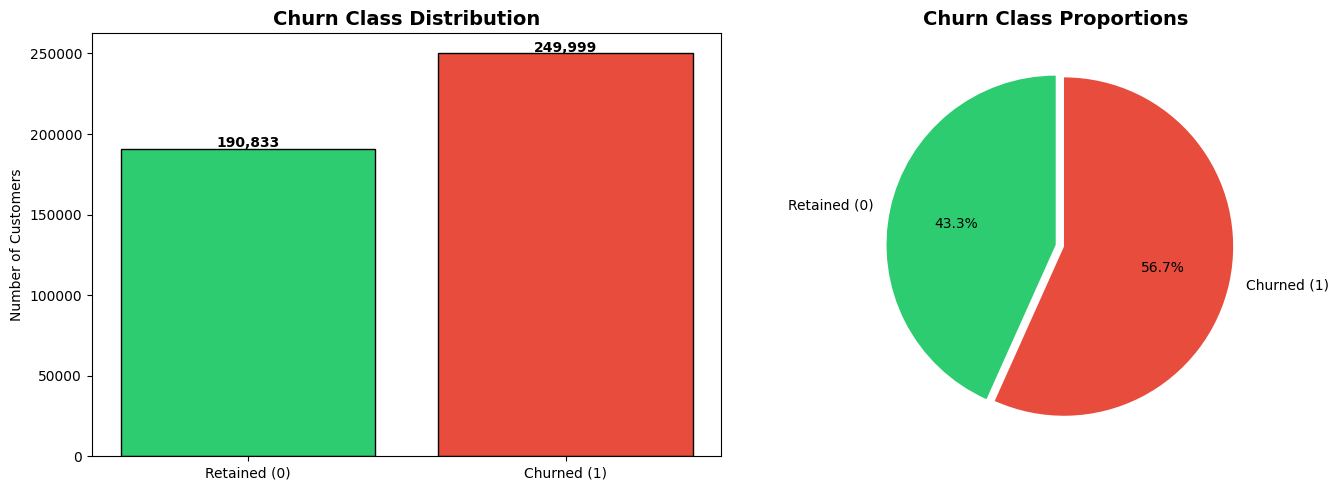

Class balance — Retained: 190,833  |  Churned: 249,999
Churn rate: 56.7%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of churn counts
churn_counts = df["Churn"].value_counts().sort_index()
colors = ["#2ecc71", "#e74c3c"]
axes[0].bar(["Retained (0)", "Churned (1)"], churn_counts.values, color=colors, edgecolor="black")
axes[0].set_title("Churn Class Distribution", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Number of Customers")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontweight="bold")

# Pie chart showing class proportions
axes[1].pie(churn_counts.values, labels=["Retained (0)", "Churned (1)"],
            autopct="%1.1f%%", colors=colors, startangle=90, explode=(0, 0.05))
axes[1].set_title("Churn Class Proportions", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"Class balance — Retained: {churn_counts.iloc[0]:,}  |  Churned: {churn_counts.iloc[1]:,}")
print(f"Churn rate: {churn_counts.iloc[1] / len(df) * 100:.1f}%")

### 3b. Distributions of Key Numeric Variables

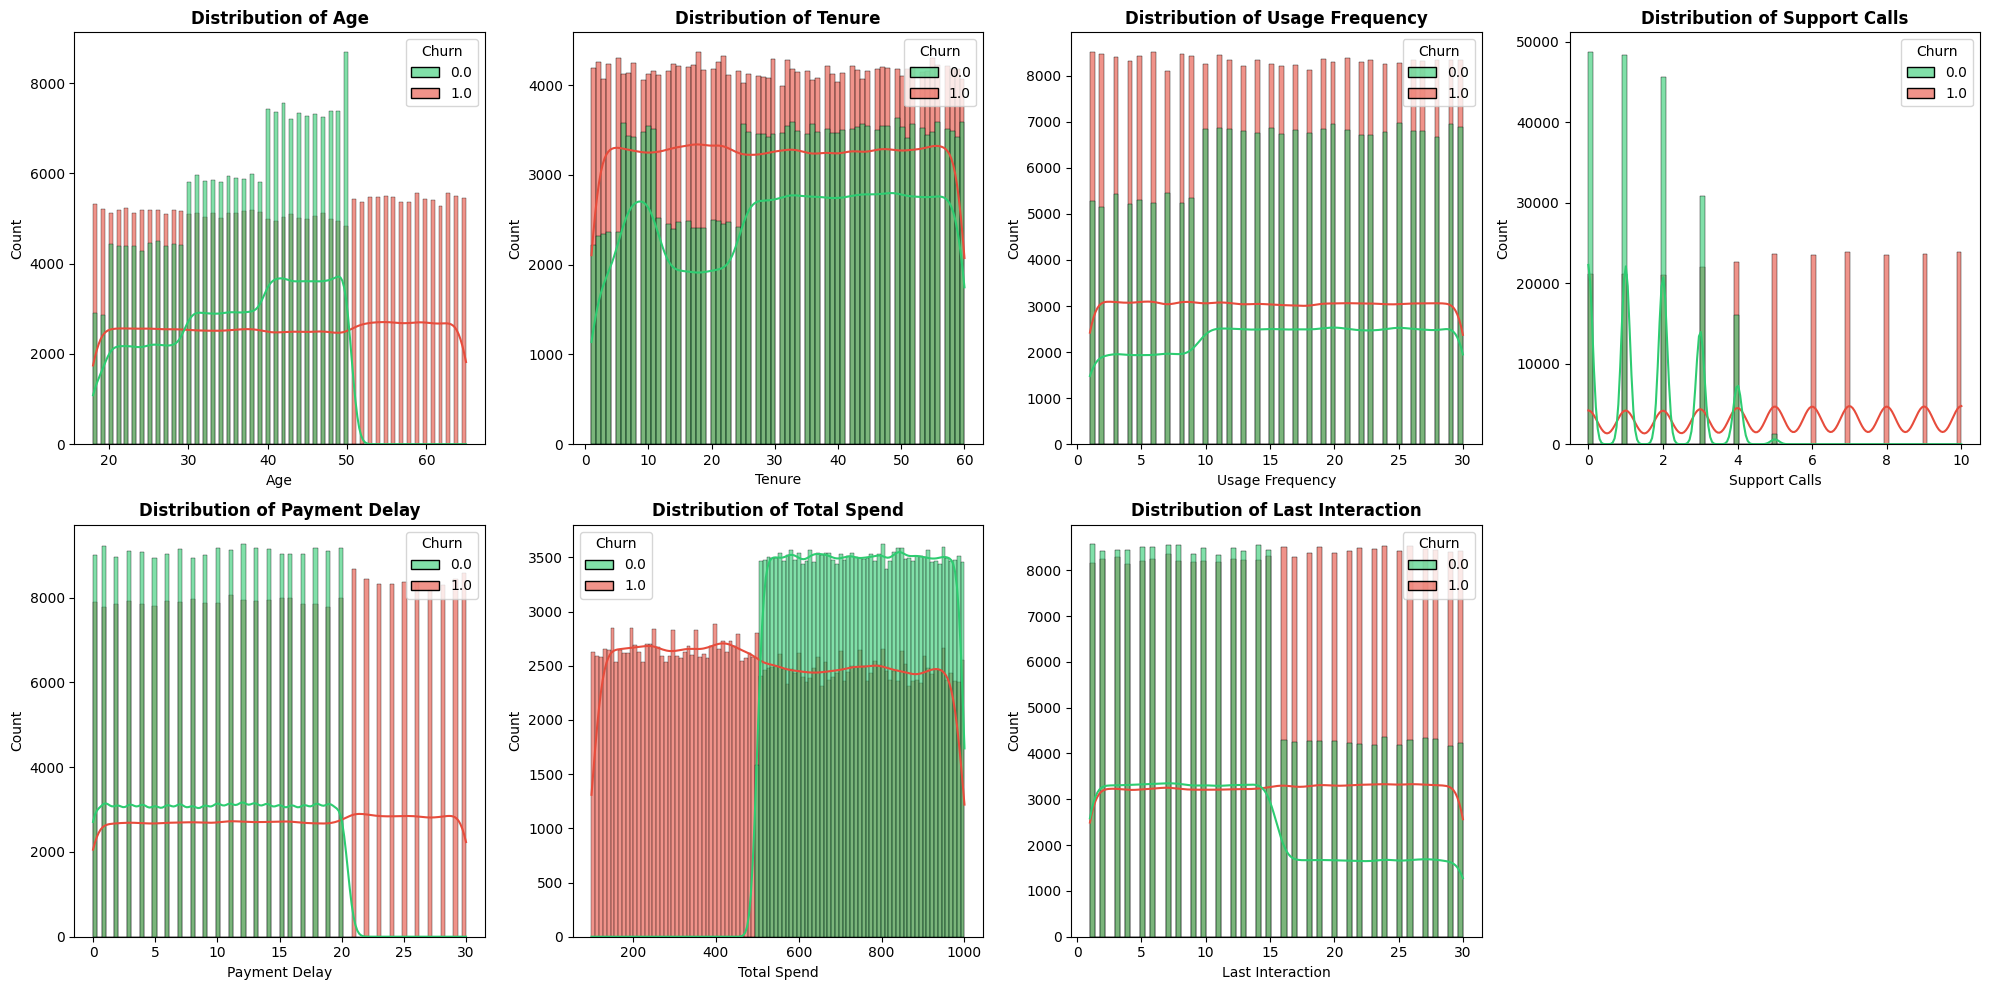

In [8]:
numeric_cols = ["Age", "Tenure", "Usage Frequency", "Support Calls",
                "Payment Delay", "Total Spend", "Last Interaction"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=axes[i],
                 palette={0: "#2ecc71", 1: "#e74c3c"}, alpha=0.6)
    axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# Hide the unused subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

### 3c. Frequency Tables for Categorical Variables

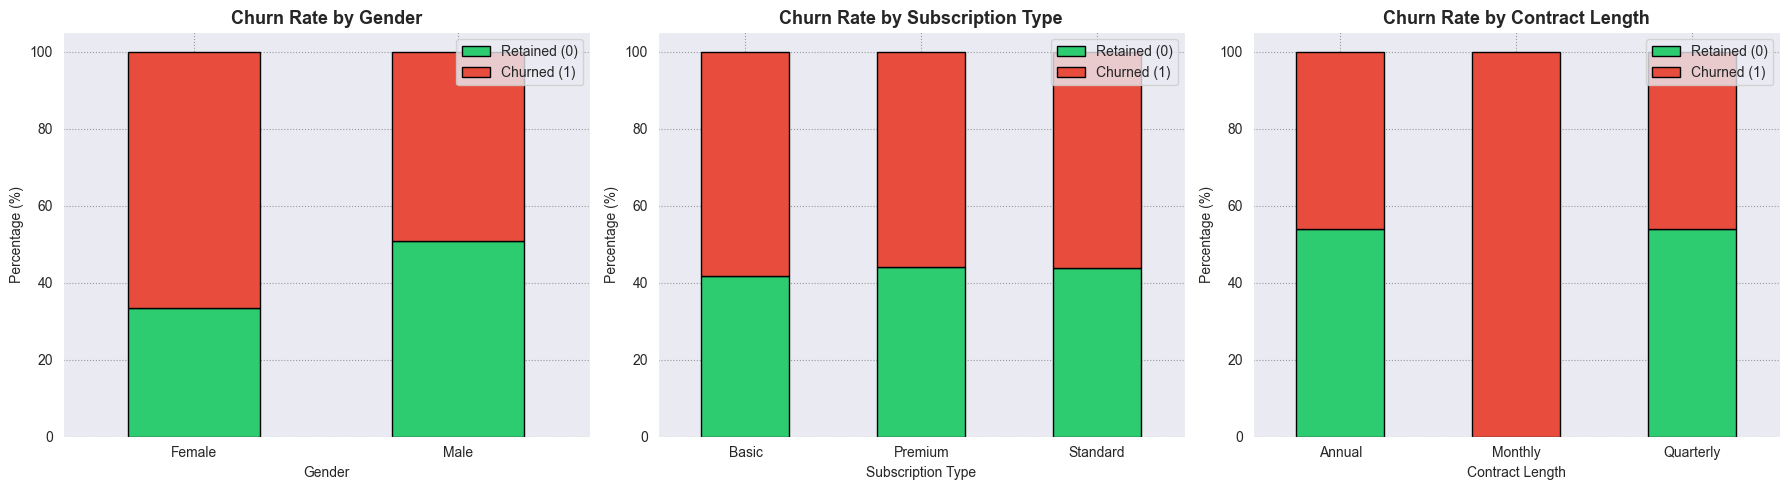

In [9]:
cat_cols = ["Gender", "Subscription Type", "Contract Length"]
sns.set_style("darkgrid", {"grid.color": ".6", "grid.linestyle": ":"})
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df["Churn"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=axes[i],
            color=["#2ecc71", "#e74c3c"], edgecolor="black")
    axes[i].set_title(f"Churn Rate by {col}", fontsize=13, fontweight="bold")
    axes[i].set_ylabel("Percentage (%)")
    axes[i].set_xlabel(col)
    axes[i].legend(["Retained (0)", "Churned (1)"], loc="upper right")
    axes[i].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### 3d. Scatterplot — Tenure vs. Total Spend (colored by Churn)

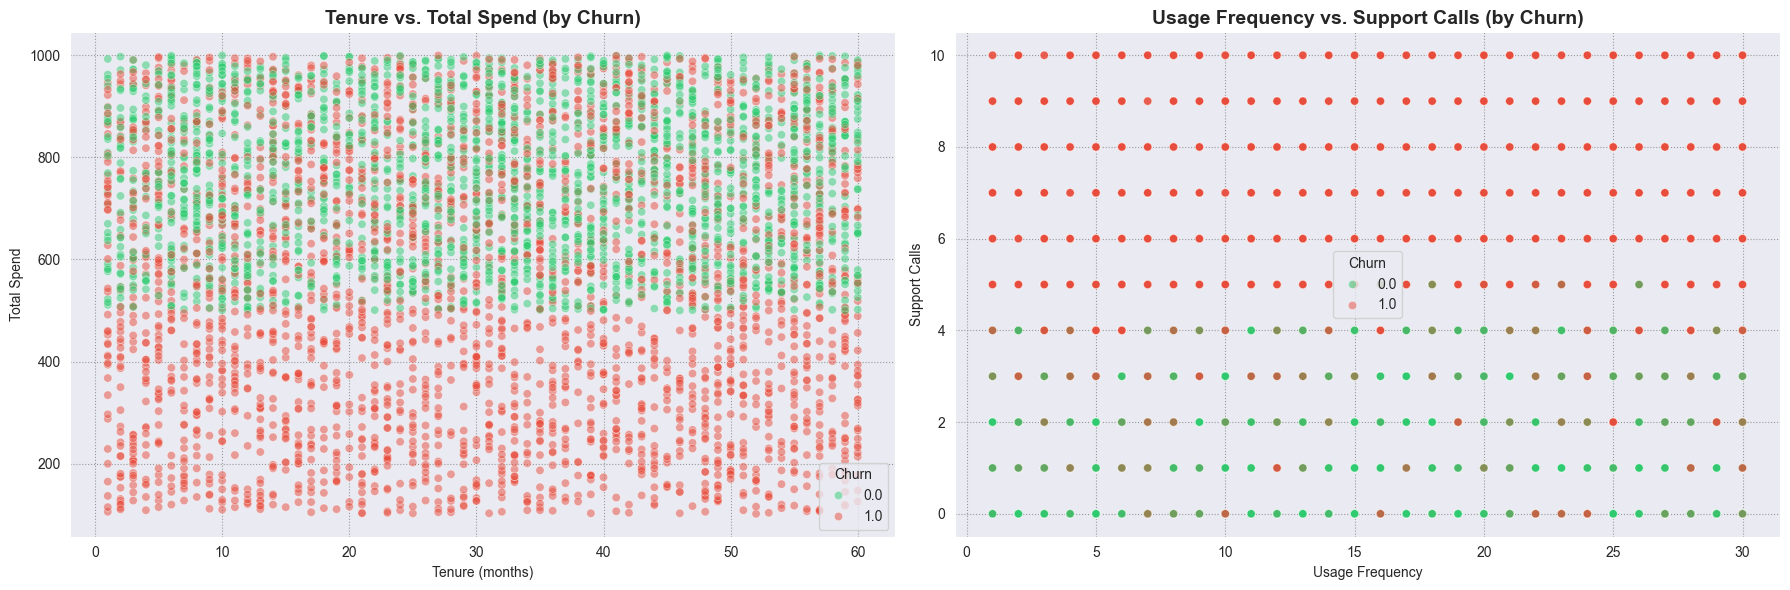

In [10]:
# Use a sample for readability (full dataset is 440K+ rows)
sample_df = df.sample(n=5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Tenure vs Total Spend
sns.scatterplot(data=sample_df, x="Tenure", y="Total Spend", hue="Churn",
                palette={0: "#2ecc71", 1: "#e74c3c"}, alpha=0.5, ax=axes[0])
axes[0].set_title("Tenure vs. Total Spend (by Churn)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Total Spend")

# Usage Frequency vs Support Calls
sns.scatterplot(data=sample_df, x="Usage Frequency", y="Support Calls", hue="Churn",
                palette={0: "#2ecc71", 1: "#e74c3c"}, alpha=0.5, ax=axes[1])
axes[1].set_title("Usage Frequency vs. Support Calls (by Churn)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Usage Frequency")
axes[1].set_ylabel("Support Calls")

plt.tight_layout()
plt.show()

### 3e. Correlation Matrix Heatmap

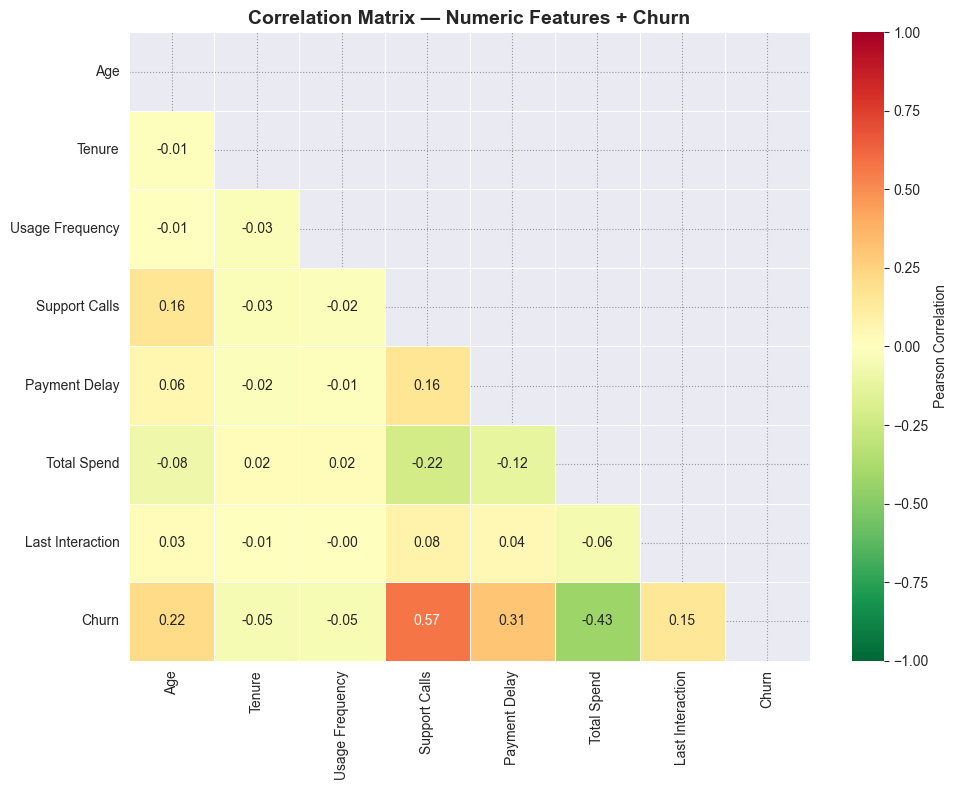

In [11]:
# Correlation matrix for all numeric columns (including the target)
numeric_df = df[numeric_cols + ["Churn"]]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # mask the upper triangle
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn_r",
            mask=mask, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={"label": "Pearson Correlation"})
plt.title("Correlation Matrix — Numeric Features + Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 3f. Boxplots — Key Features by Churn Status

C:\Users\ass\AppData\Local\Temp\ipykernel_9012\1293188622.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=col, ax=axes[i],
C:\Users\ass\AppData\Local\Temp\ipykernel_9012\1293188622.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Retained (0)", "Churned (1)"])
C:\Users\ass\AppData\Local\Temp\ipykernel_9012\1293188622.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y=col, ax=axes[i],
C:\Users\ass\AppData\Local\Temp\ipykernel_9012\1293188622.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. 

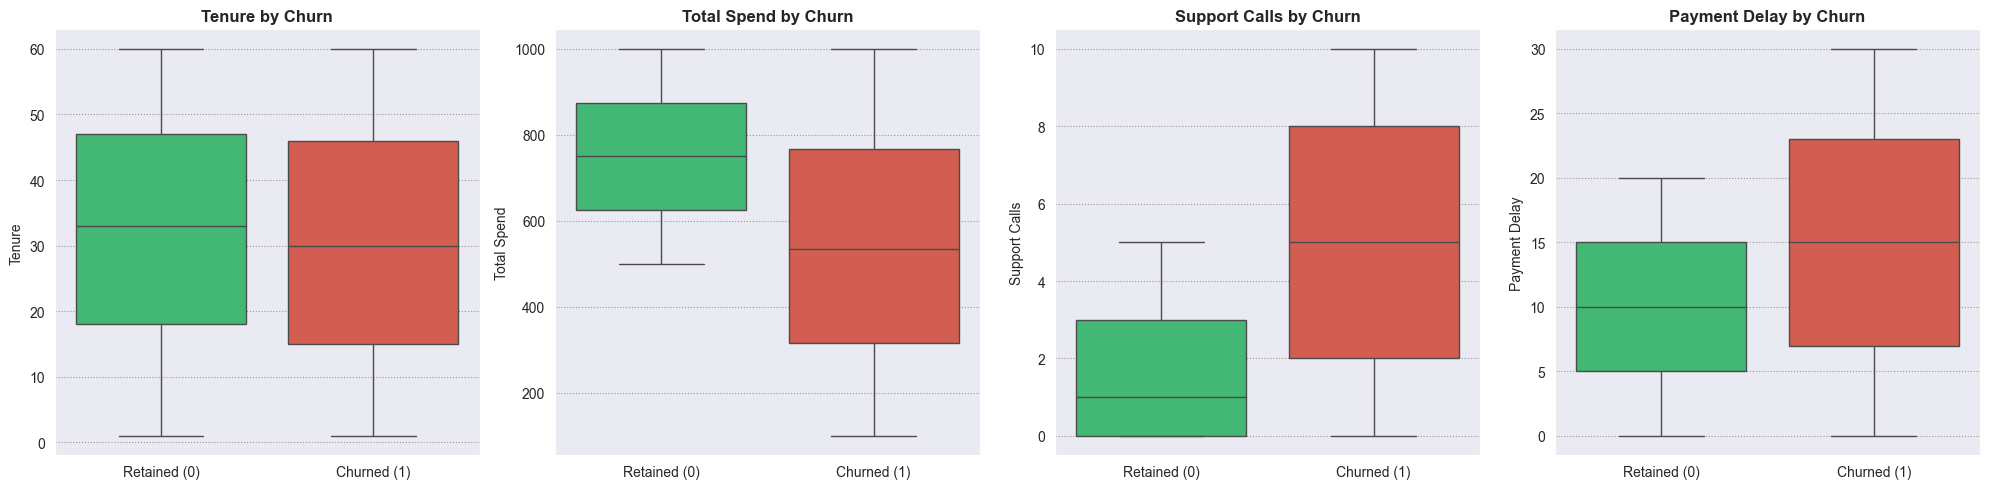

In [12]:
box_cols = ["Tenure", "Total Spend", "Support Calls", "Payment Delay"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(box_cols):
    sns.boxplot(data=df, x="Churn", y=col, ax=axes[i],
                palette={'1.0': "#e74c3c", '0.0': "#2ecc71"})
    axes[i].set_title(f"{col} by Churn", fontsize=12, fontweight="bold")
    axes[i].set_xticklabels(["Retained (0)", "Churned (1)"])
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

## 4. Interpretation of Exploratory Analysis

**Key observations from the data exploration:**

1. **Class imbalance:** The target variable `Churn` shows a roughly 50/50 split in this dataset (the exact ratio is visible in the bar/pie chart above). This is relatively balanced, which simplifies modeling — no resampling may be strictly necessary, though it should still be monitored.

2. **Tenure and Total Spend:** Customers who churn tend to have **shorter tenures** and **lower total spend**. This makes intuitive sense — newer customers who haven't invested much in the service are more likely to leave. The scatterplot shows churned customers clustering toward the lower-left (low tenure, low spend).

3. **Support Calls:** Churned customers make **significantly more support calls** on average. Frequent support interactions may signal dissatisfaction with the service, making this one of the strongest predictors of churn.

4. **Payment Delay:** Customers who churn tend to have **longer payment delays**. Late payments may indicate the customer is already disengaging from the service.

5. **Usage Frequency:** Lower usage frequency correlates with higher churn — customers who use the service less have less reason to stay.

6. **Contract Length:** Monthly contracts are expected to exhibit higher churn rates compared to quarterly or annual contracts, as there is less commitment locking the customer in.

7. **Correlation matrix:** Most features show low pairwise correlation with each other, suggesting they provide **independent signals** for churn prediction. The strongest correlates with `Churn` are likely `Support Calls`, `Payment Delay`, and `Tenure` (visible from the heatmap).

> **Summary:** The typical churning customer profile is one with a **short tenure, high support call volume, frequent payment delays, low usage, and a monthly contract**. These patterns will guide our feature engineering and model selection in the next steps.

# Data preprocessing

## Preprocessing for supervised machine learning 

### Steps 1 & 2: Load Data and Convert Target

We load both the pre-split training and testing CSVs. The `Churn` column is already encoded as `1` (churned) and `0` (retained), so we simply cast it to `int` to ensure a clean integer type for modeling.

In [16]:
# ── Step 1: Load Both Datasets ──────────────────────────────────────────────
train_df = pd.read_csv("../data/customer_churn_dataset-training-master.csv")
test_df  = pd.read_csv("../data/customer_churn_dataset-testing-master.csv")

print(f"Training set shape: {train_df.shape}")
print(f"Testing  set shape: {test_df.shape}")

train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

# ── Step 2: Target Conversion ───────────────────────────────────────────────
# The Churn column is already numeric (1 = churned, 0 = retained).
# We cast to int to remove any float representation and confirm the mapping.
train_df["Churn"] = train_df["Churn"].astype(int)
test_df["Churn"]  = test_df["Churn"].astype(int)

print(f"\nTraining target distribution:\n{train_df['Churn'].value_counts()}")
print(f"\nTesting target distribution:\n{test_df['Churn'].value_counts()}")

Training set shape: (440833, 12)
Testing  set shape: (64374, 12)

Training target distribution:
Churn
1    249999
0    190833
Name: count, dtype: int64

Testing target distribution:
Churn
0    33881
1    30493
Name: count, dtype: int64


### Train / Test Split

The data is **already provided as separate files** (`customer_churn_dataset-training-master.csv` and `customer_churn_dataset-testing-master.csv`), so no programmatic split is needed. We loaded them directly in the previous cell.

### Step 3: Feature Selection — Remove Irrelevant Attributes

We drop the following column from both datasets:

| Dropped Column | Reason |
|---|---|
| **CustomerID** | A unique row identifier with no predictive value. Including it would cause the model to memorise IDs instead of learning general patterns. |

All remaining features (`Age`, `Gender`, `Tenure`, `Usage Frequency`, `Support Calls`, `Payment Delay`, `Subscription Type`, `Contract Length`, `Total Spend`, `Last Interaction`) showed meaningful variation and correlation with `Churn` during our EDA — so none of them are zero-variance or redundant.

In [17]:
# ── Step 3: Drop irrelevant columns ─────────────────────────────────────────
drop_cols = ["CustomerID"]

train_df = train_df.drop(columns=drop_cols)
test_df  = test_df.drop(columns=drop_cols)

print("Columns after dropping CustomerID:")
print(train_df.columns.tolist())
print(f"\nTraining shape: {train_df.shape}")
print(f"Testing  shape: {test_df.shape}")

Columns after dropping CustomerID:
['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

Training shape: (440832, 11)
Testing  shape: (64374, 11)


### Step 4: Feature Engineering & Scaling

We identify the **continuous numerical features** and apply `StandardScaler` to normalise them (zero mean, unit variance). This is important because:

- Many algorithms (e.g., logistic regression, SVM, k-NN) are sensitive to feature scales.
- Features like `Total Spend` (range ~100–1000) would otherwise dominate features like `Support Calls` (range ~0–10).

**Critically**, we **fit** the scaler on the training set only and then **transform** both sets. This prevents *data leakage* — the test set must not influence any preprocessing parameters.

In [18]:
from sklearn.preprocessing import StandardScaler

# ── Identify continuous numerical features to scale ─────────────────────────
continuous_features = ["Age", "Tenure", "Usage Frequency", "Support Calls",
                       "Payment Delay", "Total Spend", "Last Interaction"]

scaler = StandardScaler()

# Fit on training data ONLY, then transform both sets
train_df[continuous_features] = scaler.fit_transform(train_df[continuous_features])
test_df[continuous_features]  = scaler.transform(test_df[continuous_features])

print("Scaler means (from training set):")
for feat, mean in zip(continuous_features, scaler.mean_):
    print(f"  {feat:20s} → {mean:.2f}")

print(f"\nTraining set after scaling:")
train_df[continuous_features].describe().round(2)

Scaler means (from training set):
  Age                  → 39.37
  Tenure               → 31.26
  Usage Frequency      → 15.81
  Support Calls        → 3.60
  Payment Delay        → 12.97
  Total Spend          → 631.62
  Last Interaction     → 14.48

Training set after scaling:


,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
count,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00,440832.00
mean,0.00,0.00,-0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.72,-1.75,-1.72,-1.17,-1.57,-2.21,-1.57
25%,-0.83,-0.88,-0.79,-0.85,-0.84,-0.63,-0.87
50%,-0.03,0.04,0.02,-0.20,-0.12,0.12,-0.06
75%,0.69,0.85,0.84,0.78,0.73,0.82,0.87
max,2.06,1.67,1.65,2.08,2.06,1.53,1.81


> **Note:** All preprocessing above follows the *fit-on-train, apply-to-test* principle. The `StandardScaler` was fitted exclusively on `train_df`; `test_df` was only transformed — never used to compute means or standard deviations.

## Verification & Export of Preprocessed Data

Let's verify the final state of both datasets and save them as `train.csv` and `test.csv` for downstream modeling.

In [ ]:
# ── Verify preprocessed training data
display(train_df.head())
print(f"\nShape: {train_df.shape}")

display(test_df.head())
print(f"\nShape: {test_df.shape}")


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,-0.753326,Female,0.448760,-0.210511,0.454549,0.609620,Standard,Annual,1.247427,0.293052,1
1,2.059646,Female,1.028278,-1.724562,2.083100,-0.601319,Basic,Monthly,-0.309865,-0.986584,1
2,1.255940,Female,-1.000036,-1.375166,0.780259,0.609620,Basic,Quarterly,-1.854698,-1.335575,1
3,1.497051,Male,0.390808,0.604748,1.105969,-0.722413,Standard,Monthly,-0.978462,1.689018,1
4,-1.315921,Male,0.043097,0.488282,0.454549,-0.601319,Basic,Monthly,-0.060698,0.642043,1



Shape: (440832, 11)


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,-1.396291,Female,-0.362566,-0.210511,0.128839,1.699466,Basic,Monthly,-0.139601,-0.637592,1
1,0.130751,Female,-0.188711,1.420007,1.105969,0.004151,Standard,Monthly,-0.197740,0.642043,0
2,0.612974,Male,-0.246662,-0.676373,-0.522581,1.941654,Premium,Annual,0.520691,0.758374,0
3,-0.351473,Male,-1.289796,-0.443442,0.454549,0.488527,Premium,Quarterly,-1.659517,0.409382,0
4,1.095198,Female,1.549845,0.954145,1.757390,-1.327882,Standard,Annual,-0.409531,0.409382,0



Shape: (64374, 11)

Preprocessed files saved: data/train.csv  &  data/test.csv


## Modeling

* Train the model on training data, and evaluate the model on test data. 
* Try at least two machine learning classification algorithms. It is recommended to try Decision Trees and Forests. 


### Classifier 1 (decision tree)

* Try various combinations of metaparameters (such as tree depth for decision tree) and record the impact on predictive performance. You can use grid search cross-validation for this.
* Once you determine the best values, you can refit the model with the best parameter value on the entire training data.

### Classifier 2 (random forest)

* Try various combinations of metaparameters (such as  number of trees in a forest) and record the impact on predictive performance. You can use grid search cross-validation for this.
* Once you determine the best values, you can refit the model with the best parameter value on the entire training data.


### Classifier 3 (baseline)

* Fit a baseline model, e.g., a model that predicts the most frequent class in the training data

# Evaluation

### Classifier 1 (decision tree)

* Compute accuracy and F1 score on test data (you can include also other measures)
* Show confusion matrix
* Multiply the predefined costs with the confusion matrix to get the overall cost of the model

### Classifier 2 (random forest)

* Compute accuracy and F1 score on test data (you can include also other measures)
* Show confusion matrix
* Multiply the predefined costs with the confusion matrix to get the overall cost of the model

### Classifier 3 (baseline)

* Compute accuracy and F1 score on test data (you can include also other measures)
* Show confusion matrix
* Multiply the predefined costs with the confusion matrix to get the overall cost of the model

### Summary

* Which metric is most suitable for use for the current problem (accuracy, F-measure)?
* Compare the performance metrics for all types of models (e.g,. decision tree and forest). Which model is the best one?
* Combine (multiply) the predefined costs matrix with the values in the confusion matrix for each model. Which model is the best one? 


# Explanation

## Global explanation

### Classifier 1 - decision tree

* Visualize the decision tree
* Looking at the tree, list the most important attributes

### Classifier 2 - random forest

* Show the feature importance of variables in the forest

## Local explanation

* Show the *instance of interest* - a row in the dataframe
* Use both models to classify the chosen instance
* Do both models assign the same class?
* What is the confidence (probability) of the prediction?
* If you change the value of the attribute of interest in the instance of interest, how does the classification of the instance change? 

# Conclusion
Summarize the results, answering questions such as:

1.	Which machine learning result has the highest value and is most interesting? 
2.	What setting provided the best result? 
3.	Which attributes are the most important?


# Optional parts

## Evaluation  - cost based

### Ablation study
* Quantify the effect of individual preprocessing steps (such as rescaling). How would the performance change if you have not performed this step (optional).

###  Optimization of threshold (optional)

* If you would change the probability (score) threshold for classification, would you obtain better results in terms of total costs? For which threshold? 

## Explanation

*	Apply ICE/IME/SHAPLEY/Anchors to explain the classification of the instance

# Final checklist

-	Are all preprocessing steps justified?
-	Did you try different metaparameter values where appropriate?
-	Are the results replicable? If you have the same data, does the report describe all steps in sufficient detail to obtain the same results as reported by the authors?
-	Were proper evaluation metrics selected? Are the results correctly interpreted?
-	Are all important steps explained and justified?
-	What is the quality of writing? Is the language clear and concise?


# Submission

* This .ipynb file with your code + its html version after the code was run (File-Save and export notebook as - html)
* Source data or a link to source data or source data being loaded from a url in the notebook
* Data files after preprorcessing (train.csv and test.csv)